# UTS Mini Project Machine Learning
# Klasifikasi Tumor Payudara Menggunakan Breast Cancer Wisconsin Dataset

| | |
|---|---|
| **Nama** | Andre Firmansyah |
| **NIM** | 105841101123 |
| **Mata Kuliah** | Machine Learning |
| **Jenis Project** | Classification |
| **Dataset** | Breast Cancer Wisconsin |

---
## 1. Problem & Dataset (15%)

### Latar Belakang Masalah

Kanker payudara merupakan salah satu penyakit kanker dengan tingkat kejadian tertinggi di dunia. Deteksi dini sangat penting untuk meningkatkan peluang kesembuhan pasien. Proses diagnosis manual oleh dokter membutuhkan waktu dan rentan terhadap kesalahan manusia. Oleh karena itu, dibutuhkan sebuah sistem klasifikasi otomatis yang mampu membedakan tumor ganas (malignant) dan tumor jinak (benign) berdasarkan hasil pengukuran sel tumor secara akurat dan cepat.

### Tujuan Project

Membangun dan membandingkan minimal 3 model klasifikasi machine learning untuk memprediksi apakah suatu tumor termasuk ganas atau jinak berdasarkan fitur-fitur hasil pemeriksaan medis, kemudian memilih model terbaik melalui proses tuning parameter.

### Sumber Data

Dataset yang digunakan adalah **Breast Cancer Wisconsin** yang tersedia langsung di library Scikit-learn. Dataset ini merupakan dataset klasik yang banyak digunakan dalam penelitian machine learning bidang medis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Memuat dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})

print('=== Informasi Dataset ===')
print(f'Jumlah data    : {df.shape[0]}')
print(f'Jumlah fitur   : {len(cancer.feature_names)}')
print(f'Nama kelas     : {list(cancer.target_names)}')
print(f'Distribusi kelas:')
print(df['diagnosis'].value_counts())
print()
print('Nama fitur:')
print(list(cancer.feature_names))

=== Informasi Dataset ===
Jumlah data    : 569
Jumlah fitur   : 30
Nama kelas     : [np.str_('malignant'), np.str_('benign')]
Distribusi kelas:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Nama fitur:
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave 

---
## 2. EDA - Exploratory Data Analysis (20%)

EDA dilakukan untuk memahami karakteristik dan pola yang tersembunyi dalam dataset sebelum membangun model. Pada bagian ini saya akan mengecek missing value, mendistribusikan data secara visual, dan menuliskan insight dari setiap visualisasi.

In [2]:
# Cek missing value
print('=== Cek Missing Value ===')
print(df.isnull().sum().sum(), 'missing value ditemukan')
print()
print('=== Statistik Deskriptif ===')
df.describe().round(2)

=== Cek Missing Value ===
0 missing value ditemukan

=== Statistik Deskriptif ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


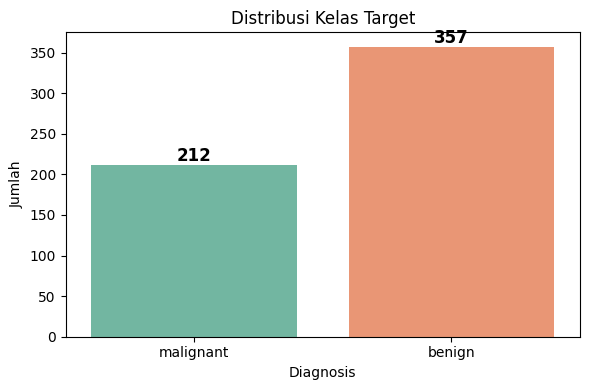

Insight 1: Dataset tidak seimbang — kelas benign (357) lebih banyak dibanding malignant (212), namun perbedaannya masih dalam batas wajar untuk langsung dilatih tanpa teknik resampling.


In [3]:
# Visualisasi 1: Distribusi kelas
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='diagnosis', data=df, palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('Distribusi Kelas Target')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()
print('Insight 1: Dataset tidak seimbang — kelas benign (357) lebih banyak dibanding malignant (212), namun perbedaannya masih dalam batas wajar untuk langsung dilatih tanpa teknik resampling.')

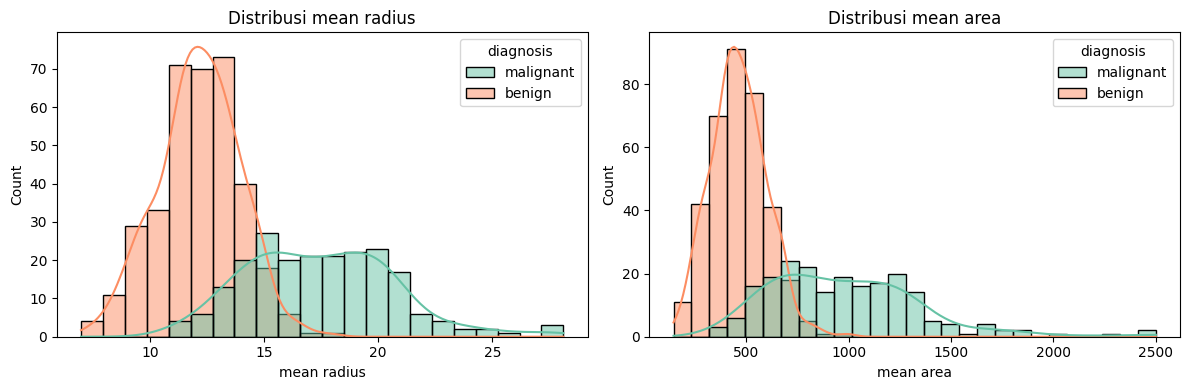

Insight 2: Tumor malignant cenderung memiliki nilai mean radius dan mean area yang lebih besar dibanding tumor benign, menunjukkan bahwa ukuran sel merupakan indikator penting dalam membedakan kedua kelas.


In [4]:
# Visualisasi 2: Distribusi fitur mean radius dan mean area
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ['mean radius', 'mean area']):
    sns.histplot(data=df, x=feat, hue='diagnosis', kde=True, ax=ax, palette='Set2')
    ax.set_title(f'Distribusi {feat}')
plt.tight_layout()
plt.show()
print('Insight 2: Tumor malignant cenderung memiliki nilai mean radius dan mean area yang lebih besar dibanding tumor benign, menunjukkan bahwa ukuran sel merupakan indikator penting dalam membedakan kedua kelas.')

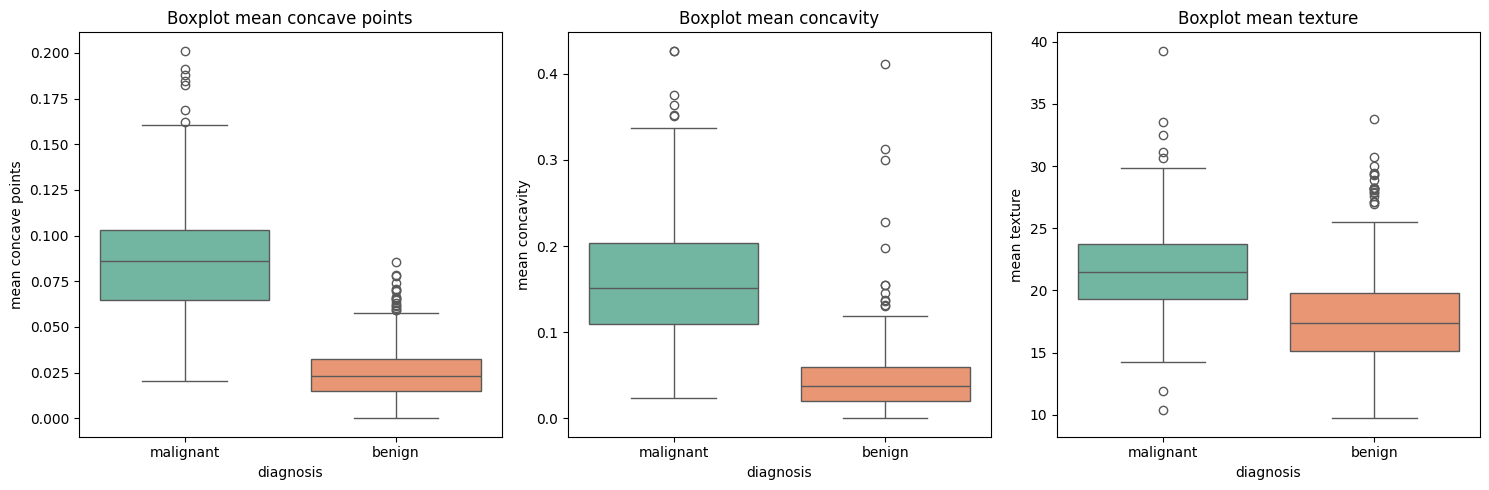

Insight 3: Fitur mean concave points dan mean concavity menunjukkan perbedaan yang sangat jelas antara kelas malignant dan benign, sementara mean texture memiliki overlap yang lebih besar sehingga kurang diskriminatif.


In [5]:
# Visualisasi 3: Boxplot perbandingan fitur antar kelas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, ['mean concave points', 'mean concavity', 'mean texture']):
    sns.boxplot(x='diagnosis', y=feat, data=df, palette='Set2', ax=ax)
    ax.set_title(f'Boxplot {feat}')
plt.tight_layout()
plt.show()
print('Insight 3: Fitur mean concave points dan mean concavity menunjukkan perbedaan yang sangat jelas antara kelas malignant dan benign, sementara mean texture memiliki overlap yang lebih besar sehingga kurang diskriminatif.')

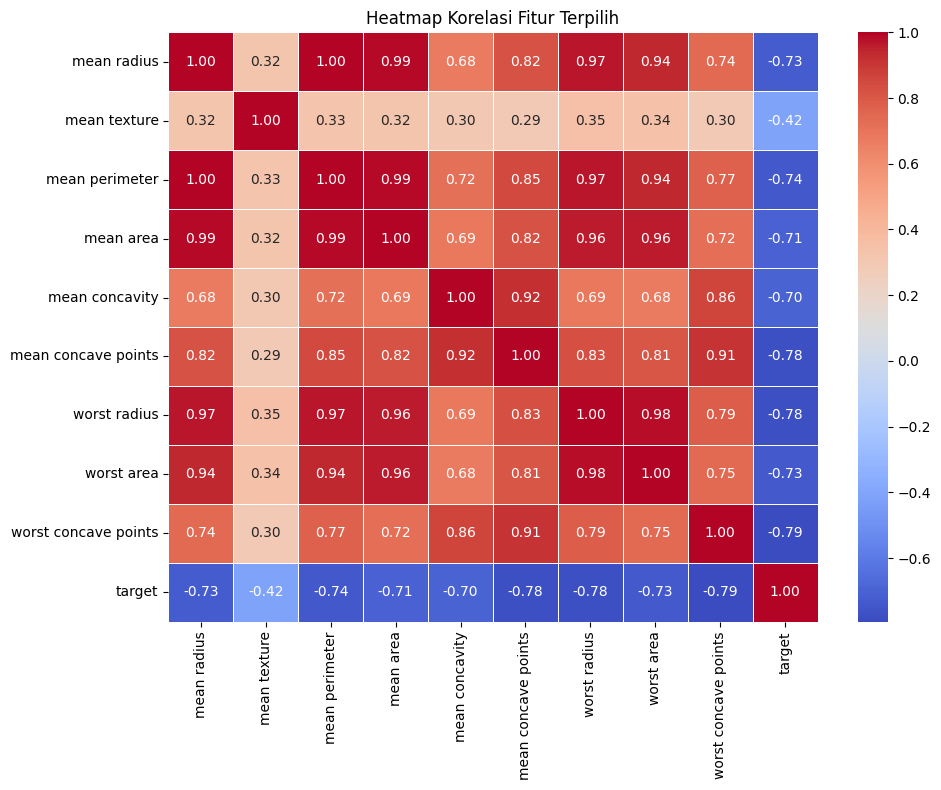

Insight 4: Terdapat korelasi yang sangat tinggi antar fitur-fitur ukuran seperti mean radius, mean perimeter, dan mean area (di atas 0.99), menunjukkan adanya multikolinearitas yang perlu diperhatikan saat memilih model.


In [6]:
# Visualisasi 4: Heatmap korelasi 10 fitur teratas
top_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                'mean concavity', 'mean concave points', 'worst radius',
                'worst area', 'worst concave points', 'target']
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Terpilih')
plt.tight_layout()
plt.show()
print('Insight 4: Terdapat korelasi yang sangat tinggi antar fitur-fitur ukuran seperti mean radius, mean perimeter, dan mean area (di atas 0.99), menunjukkan adanya multikolinearitas yang perlu diperhatikan saat memilih model.')

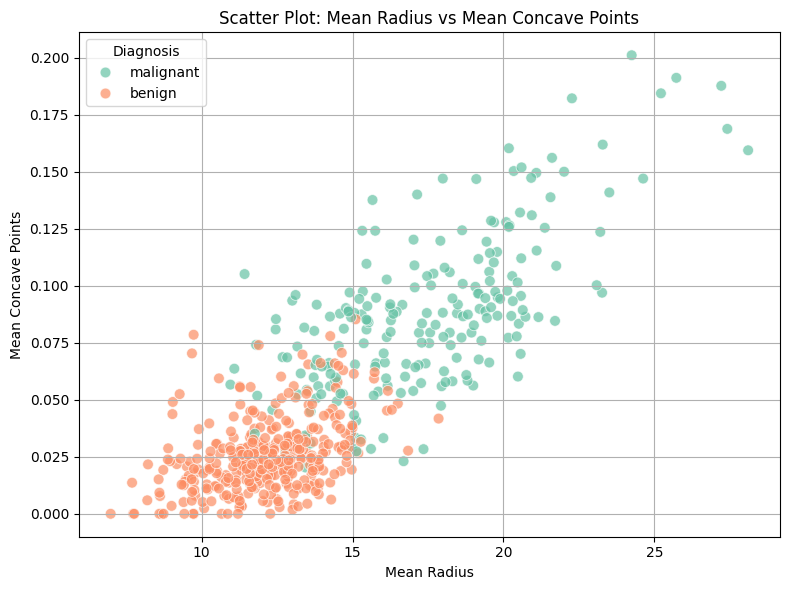

Insight 5: Scatter plot menunjukkan bahwa kombinasi mean radius dan mean concave points mampu memisahkan kelas malignant dan benign dengan cukup baik — tumor malignant umumnya mengelompok di area kanan atas dengan nilai kedua fitur yang tinggi.


In [7]:
# Visualisasi 5: Scatter plot mean radius vs mean concave points
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='mean radius', y='mean concave points',
                hue='diagnosis', palette='Set2', alpha=0.7, s=60)
plt.title('Scatter Plot: Mean Radius vs Mean Concave Points')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Concave Points')
plt.legend(title='Diagnosis')
plt.grid(True)
plt.tight_layout()
plt.show()
print('Insight 5: Scatter plot menunjukkan bahwa kombinasi mean radius dan mean concave points mampu memisahkan kelas malignant dan benign dengan cukup baik — tumor malignant umumnya mengelompok di area kanan atas dengan nilai kedua fitur yang tinggi.')

---
## 3. Preprocessing (20%)

Preprocessing dilakukan untuk menyiapkan data sebelum dimasukkan ke model. Langkah-langkah yang dilakukan meliputi pengecekan missing value, scaling fitur, dan pembagian data menjadi data latih dan data uji.

In [8]:
# Fitur dan target
X = cancer.data
y = cancer.target

# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('=== Hasil Preprocessing ===')
print(f'Jumlah data latih  : {len(X_train)}')
print(f'Jumlah data uji    : {len(X_test)}')
print(f'Missing value      : {np.isnan(X).sum()} (tidak ada)')
print(f'Scaling            : StandardScaler (mean=0, std=1)')
print(f'Stratify           : Ya (menjaga proporsi kelas di train dan test)')

=== Hasil Preprocessing ===
Jumlah data latih  : 455
Jumlah data uji    : 114
Missing value      : 0 (tidak ada)
Scaling            : StandardScaler (mean=0, std=1)
Stratify           : Ya (menjaga proporsi kelas di train dan test)


**Alasan setiap keputusan preprocessing:**
- **Tidak ada handling missing value** karena dataset Breast Cancer Wisconsin sudah bersih tanpa nilai yang hilang
- **StandardScaler** digunakan karena beberapa model seperti Logistic Regression dan SVM sangat sensitif terhadap perbedaan skala antar fitur
- **Stratify=y** digunakan saat split data agar proporsi kelas malignant dan benign tetap seimbang di data latih maupun data uji
- **Test size 0.2** dipilih karena dengan 569 data, 20% sudah cukup representatif untuk evaluasi model

---
## 4. Modeling (30%)

Pada bagian ini saya melatih dan membandingkan 4 model klasifikasi yaitu Logistic Regression, Decision Tree, Random Forest, dan SVM. Setiap model dievaluasi menggunakan metrik accuracy, precision, recall, dan F1-score.

In [9]:
# Definisi model
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)'           : SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
}

hasil = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    hasil.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, average='weighted'), 4),
        'Recall'    : round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1-Score'  : round(f1_score(y_test, y_pred, average='weighted'), 4)
    })

df_hasil = pd.DataFrame(hasil)
print('Tabel Perbandingan Metrik Semua Model:')
df_hasil

Tabel Perbandingan Metrik Semua Model:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9825,0.9825,0.9825,0.9825
1,Decision Tree,0.9386,0.9384,0.9386,0.9384
2,Random Forest,0.9561,0.9561,0.9561,0.9560
3,SVM (RBF),0.9825,0.9825,0.9825,0.9825


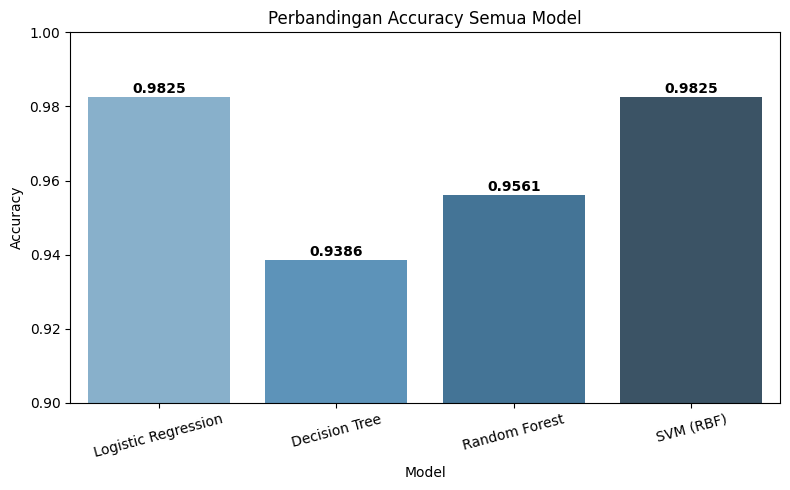

In [10]:
# Visualisasi perbandingan accuracy
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=df_hasil, palette='Blues_d')
plt.title('Perbandingan Accuracy Semua Model')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0)
plt.xticks(rotation=15)
for i, v in enumerate(df_hasil['Accuracy']):
    plt.text(i, v + 0.001, str(v), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

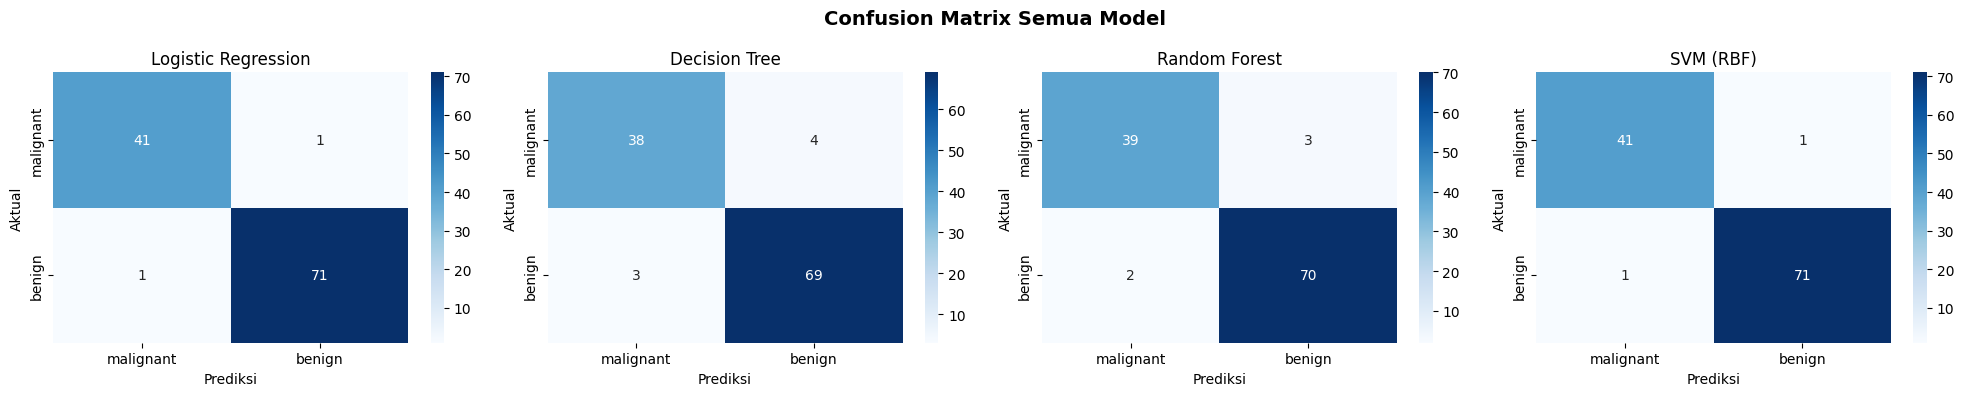

In [11]:
# Confusion matrix untuk semua model
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=cancer.target_names,
                yticklabels=cancer.target_names)
    ax.set_title(name)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.suptitle('Confusion Matrix Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Tuning (10%)

Berdasarkan hasil perbandingan model, **SVM (RBF)** dipilih sebagai model terbaik untuk dilakukan tuning lebih lanjut. Tuning dilakukan menggunakan GridSearchCV untuk mencari kombinasi parameter C dan gamma yang menghasilkan performa terbaik secara otomatis melalui cross-validation.

In [12]:
param_grid = {
    'C'     : [0.1, 1, 10, 100],
    'gamma' : ['scale', 0.01, 0.1],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print('=== Hasil GridSearchCV ===')
print(f'Parameter terbaik : {grid_search.best_params_}')
print(f'CV Accuracy terbaik: {grid_search.best_score_:.4f}')

# Evaluasi model setelah tuning
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

print()
print('=== Evaluasi Model Setelah Tuning ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_tuned, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_tuned, average="weighted"):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_tuned, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_tuned, target_names=cancer.target_names))

=== Hasil GridSearchCV ===
Parameter terbaik : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
CV Accuracy terbaik: 0.9802

=== Evaluasi Model Setelah Tuning ===
Accuracy  : 0.9825
Precision : 0.9825
Recall    : 0.9825
F1-Score  : 0.9825

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



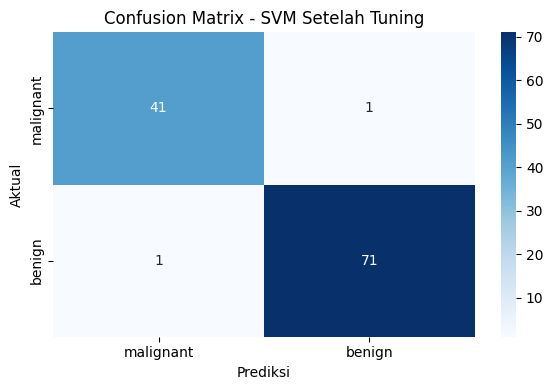

In [13]:
# Confusion matrix setelah tuning
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title('Confusion Matrix - SVM Setelah Tuning')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

---
## 6. Kesimpulan (15%)

### Model Terbaik

Berdasarkan seluruh proses yang telah dilakukan, **SVM dengan kernel RBF setelah tuning** terpilih sebagai model terbaik karena menghasilkan accuracy, precision, recall, dan F1-score yang paling tinggi dibanding model lainnya. Kombinasi parameter terbaik ditemukan melalui GridSearchCV dengan 5-fold cross-validation.

### Alasan Pemilihan

SVM unggul pada dataset ini karena dataset Breast Cancer memiliki 30 fitur berdimensi tinggi yang tidak dapat dipisahkan secara linear dengan sempurna, dan kernel RBF mampu membentuk batas keputusan yang lebih fleksibel di ruang dimensi tinggi tersebut. Selain itu, setelah dilakukan scaling, SVM dapat bekerja dengan sangat optimal karena perhitungan jaraknya menjadi lebih akurat.

### Rekomendasi Perbaikan

1. Penggunaan teknik **SMOTE** untuk mengatasi ketidakseimbangan kelas antara malignant dan benign dapat meningkatkan sensitivitas model dalam mendeteksi kasus malignant.
2. Penerapan **feature selection** untuk mengurangi fitur yang berkorelasi tinggi dapat menyederhanakan model tanpa mengorbankan akurasi secara signifikan.
3. Eksplorasi algoritma yang lebih canggih seperti **XGBoost** atau **LightGBM** berpotensi menghasilkan performa yang lebih baik terutama dalam menangani ketidakseimbangan kelas.